# Egypt's Energy Sector: Understanding the 2023 Electricity Crisis Through Data

This project examines whether the electricity supply disruptions experienced in Egypt during the summer of 2023 were caused by a shortage in generation capacity, using twenty years of national energy and economic data.

**Data sources:** `Annual_Panel_16countries` (2000-2023, 16 countries), `Monthly_Gas_Egypt` (2011-2025), `Suez_Canal_Revenue`, `Zohr_National_Gas_Timeline`, `Electricity_Tariffs`.

**Workflow:** Load & Explore, Data Cleaning, Feature Engineering, Predictive Modeling, Visualization, Analytical Questions, Key Insights.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

NILE_RED, GOLD_DESERT, NILE_BLUE, DEEP_BLACK = '#CE1126', '#C09A3E', '#1B6CA8', '#1B1B1B'
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 100


## Part 1 — Load & Explore

In [2]:
FILE = 'Egypt_Energy_Project.xlsx'
sheets = pd.read_excel(FILE, sheet_name=None)
for name, sdf in sheets.items():
    print(f"{name:32s} shape={sdf.shape}")


Annual_Panel_16countries         shape=(384, 26)
Monthly_Gas_Egypt                shape=(184, 19)
Suez_Canal_Revenue               shape=(22, 3)
Zohr_National_Gas_Timeline       shape=(20, 4)
Electricity_Tariffs              shape=(77, 4)


In [3]:
panel = sheets['Annual_Panel_16countries'].copy()
gas_m = sheets['Monthly_Gas_Egypt'].copy()
suez  = sheets['Suez_Canal_Revenue'].copy()
zohr  = sheets['Zohr_National_Gas_Timeline'].copy()
tariffs = sheets['Electricity_Tariffs'].copy()
panel.head()


,country,year,iso_code,region,income_group,population,gdp,electricity_generation,electricity_demand,electricity_demand_per_capita,net_elec_imports,net_elec_imports_share_demand,gas_production,gas_consumption,gas_prod_per_capita,gas_share_elec,gas_share_energy,oil_production,oil_consumption,renewables_electricity,renewables_share_elec,fossil_electricity,fossil_share_elec,energy_per_capita,greenhouse_gas_emissions,gdp_worldbank_usd
0,Algeria,2000,DZA,Middle East & North Africa,Upper middle income,30903894,2.085542e+11,25.40,25.33,819.638,-0.07,-0.276,918.886,191.013,29733.676,96.772,63.685,776.733,103.132,0.05,0.197,25.35,99.803,9705.756,16.22,5.479040e+10
1,Algeria,2001,DZA,Middle East & North Africa,Upper middle income,31331226,2.234203e+11,26.62,26.57,848.036,-0.05,-0.188,864.725,197.322,27599.475,96.844,63.488,764.684,106.775,0.07,0.263,26.55,99.737,9920.229,16.99,5.941340e+10
2,Algeria,2002,DZA,Middle East & North Africa,Upper middle income,31750832,2.453609e+11,27.65,27.63,870.213,-0.02,-0.072,889.416,194.839,28012.365,97.613,60.520,824.497,118.397,0.06,0.217,27.59,99.783,10139.907,17.64,6.151610e+10
3,Algeria,2003,DZA,Middle East & North Africa,Upper middle income,32175813,2.735686e+11,29.57,29.58,919.324,0.01,0.034,938.576,205.932,29170.230,96.787,61.130,918.828,123.174,0.26,0.879,29.31,99.121,10471.285,18.75,7.348226e+10
4,Algeria,2004,DZA,Middle East & North Africa,Upper middle income,32628286,2.967736e+11,31.25,31.26,958.064,0.01,0.032,920.549,211.899,28213.230,96.992,60.589,971.698,128.747,0.25,0.800,31.00,99.200,10720.079,19.83,9.191368e+10


Countries and categories covered by the panel dataset.

In [4]:
print('Countries:', sorted(panel['country'].unique()))
print('Regions:', panel['region'].unique())
print('Income groups:', panel['income_group'].unique())


Countries: ['Algeria', 'Egypt', 'Ethiopia', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Libya', 'Morocco', 'Nigeria', 'Saudi Arabia', 'South Africa', 'Sudan', 'Tunisia', 'Turkey', 'United Arab Emirates']
Regions: <StringArray>
['Middle East & North Africa', 'Sub-Saharan Africa', 'Europe & Central Asia']
Length: 3, dtype: str
Income groups: <StringArray>
['Upper middle income', 'Lower middle income', 'Low income', 'High income']
Length: 4, dtype: str


Missing values per sheet.

In [5]:
for name, sdf in sheets.items():
    print(f"{name:32s} missing cells: {sdf.isnull().sum().sum()}")


Annual_Panel_16countries         missing cells: 0
Monthly_Gas_Egypt                missing cells: 0
Suez_Canal_Revenue               missing cells: 0
Zohr_National_Gas_Timeline       missing cells: 0
Electricity_Tariffs              missing cells: 0


Duplicate rows per sheet.

In [6]:
for name, sdf in sheets.items():
    print(f"{name:32s} duplicate rows: {sdf.duplicated().sum()}")


Annual_Panel_16countries         duplicate rows: 0
Monthly_Gas_Egypt                duplicate rows: 0
Suez_Canal_Revenue               duplicate rows: 0
Zohr_National_Gas_Timeline       duplicate rows: 1
Electricity_Tariffs              duplicate rows: 0


Checking the duplicate flagged in the Zohr timeline.

In [7]:
zohr[zohr.duplicated(subset=['year','month'], keep=False)]


,year,month,national_gas_production_bcf_d,zohr_bcf_d
1,2017,Dec,5.50,0.35
2,2017,Dec,5.60,0.80
12,2023,Dec,5.52,2.00
13,2023,Dec,5.52,2.00


No missing values were found. One duplicate row exists in the Zohr timeline, and the Zohr and Suez Canal sheets are not in chronological order — both are corrected in Part 2.

## Part 2 — Data Cleaning

Remove the duplicate row identified in the Zohr timeline.

In [8]:
zohr = zohr.drop_duplicates(subset=['year','month'], keep='first').copy()


Build a proper date column and sort the Zohr timeline chronologically.

In [9]:
zohr['date'] = pd.to_datetime(zohr['year'].astype(str) + '-' + zohr['month'], format='%Y-%b')
zohr = zohr.sort_values('date').reset_index(drop=True)
zohr.head()


,year,month,national_gas_production_bcf_d,zohr_bcf_d,date
0,2015,Aug,4.20,0.00,2015-08-01
1,2017,Dec,5.50,0.35,2017-12-01
2,2018,Apr,5.65,1.10,2018-04-01
3,2018,May,5.70,1.20,2018-05-01
4,2018,Aug,5.85,2.00,2018-08-01


The Suez Canal sheet reports both calendar-year and fiscal-year figures for the same years; the calendar-year series is kept for consistency with the rest of the data.

In [10]:
suez_calendar = suez[suez['year_type'] == 'calendar'].sort_values('year').reset_index(drop=True)
suez_calendar = suez_calendar[['year','revenue_usd_billion']]
suez_calendar.head()


,year,revenue_usd_billion
0,2009,3.900
1,2014,5.465
2,2015,5.175
3,2016,5.005
4,2017,5.277


Parse the monthly gas date column and sort chronologically.

In [11]:
gas_m['month'] = pd.to_datetime(gas_m['month'], format='%Y-%m')
gas_m = gas_m.sort_values('month').reset_index(drop=True)
gas_m['year'] = gas_m['month'].dt.year


Confirm that gas trade and production volumes contain no negative values.

In [12]:
flow_cols = ['exports_lng_m3','exports_pipeline_m3','imports_lng_m3','imports_pipeline_m3',
             'indigenous_production_m3','total_demand_calc_m3']
print('Negative values present:', (gas_m[flow_cols] < 0).any().any())


Negative values present: False


Confirm that electricity tariffs increase consistently with usage tier in every year.

In [13]:
bad_years = tariffs.sort_values(['year','tier']).groupby('year')['price_EGP_per_kwh'].apply(
    lambda s: not s.is_monotonic_increasing)
print('Years with a pricing-order inconsistency:', bad_years[bad_years].index.tolist())


Years with a pricing-order inconsistency: [2016, 2017]


Extract the Egypt subset of the panel, sorted by year, for use throughout the notebook.

In [14]:
egypt = panel[panel['country'] == 'Egypt'].sort_values('year').reset_index(drop=True)
egypt.head()


,country,year,iso_code,region,income_group,population,gdp,electricity_generation,electricity_demand,electricity_demand_per_capita,net_elec_imports,net_elec_imports_share_demand,gas_production,gas_consumption,gas_prod_per_capita,gas_share_elec,gas_share_energy,oil_production,oil_consumption,renewables_electricity,renewables_share_elec,fossil_electricity,fossil_share_elec,energy_per_capita,greenhouse_gas_emissions,gdp_worldbank_usd
0,Egypt,2000,EGY,Middle East & North Africa,Lower middle income,73083287,4.442503e+11,73.32,73.17,1001.186,-0.15,-0.205,202.125,192.500,2765.680,57.542,34.012,452.605,323.759,14.26,19.449,59.06,80.551,7779.254,38.54,9.983854e+10
1,Egypt,2001,EGY,Middle East & North Africa,Lower middle income,74652035,4.756790e+11,80.71,80.50,1078.336,-0.21,-0.261,242.550,235.812,3249.074,60.055,39.917,437.289,305.734,14.59,18.077,66.12,81.923,7947.725,43.08,9.668464e+10
2,Egypt,2002,EGY,Middle East & North Africa,Lower middle income,76239140,5.019123e+11,86.23,85.45,1120.815,-0.78,-0.913,262.763,255.062,3446.557,66.624,41.972,433.108,304.168,14.20,16.468,72.03,83.532,8004.338,46.82,8.514607e+10
3,Egypt,2003,EGY,Middle East & North Africa,Lower middle income,77853548,5.287505e+11,92.19,91.27,1172.329,-0.92,-1.008,289.713,285.862,3721.250,69.444,44.411,431.153,311.878,13.23,14.351,78.96,85.649,8297.523,51.26,8.028846e+10
4,Egypt,2004,EGY,Middle East & North Africa,Lower middle income,79477441,5.615979e+11,98.25,97.55,1227.392,-0.70,-0.718,317.625,305.112,3996.417,75.776,44.885,405.197,328.398,13.33,13.567,84.92,86.433,8581.729,55.01,7.878247e+10


## Part 3 — Feature Engineering

Electricity gap: generation minus demand, the central variable for assessing whether a supply shortage occurred.

In [15]:
panel['electricity_gap'] = panel['electricity_generation'] - panel['electricity_demand']
panel['electricity_gap_pct_of_demand'] = (panel['electricity_gap'] / panel['electricity_demand'] * 100).round(2)


Gas self-sufficiency ratio (production divided by consumption). Countries with no gas sector at all report 0/0, which is replaced with 0 rather than left undefined.

In [16]:
panel['gas_self_sufficiency'] = (panel['gas_production'] / panel['gas_consumption']).round(3)
no_gas_sector = (panel['gas_production'] == 0) & (panel['gas_consumption'] == 0)
panel.loc[no_gas_sector, 'gas_self_sufficiency'] = 0


GDP per capita, computed from population and GDP.

In [17]:
panel['gdp_per_capita_usd'] = (panel['gdp_worldbank_usd'] / panel['population']).round(1)
egypt = panel[panel['country'] == 'Egypt'].sort_values('year').reset_index(drop=True)
egypt[['year','electricity_generation','electricity_demand','electricity_gap','gas_self_sufficiency']]


,year,electricity_generation,electricity_demand,electricity_gap,gas_self_sufficiency
0,2000,73.32,73.17,0.15,1.050
1,2001,80.71,80.50,0.21,1.029
2,2002,86.23,85.45,0.78,1.030
3,2003,92.19,91.27,0.92,1.013
4,2004,98.25,97.55,0.70,1.041
5,2005,104.94,104.16,0.78,1.345
6,2006,111.66,111.31,0.35,1.499
7,2007,119.86,119.30,0.56,1.452
8,2008,128.80,127.90,0.90,1.444
9,2009,134.27,133.33,0.94,1.474


Egypt's monthly gas trade balance (exports minus imports).

In [18]:
gas_m['total_exports_calc'] = gas_m['exports_lng_m3'] + gas_m['exports_pipeline_m3']
gas_m['total_imports_calc'] = gas_m['imports_lng_m3'] + gas_m['imports_pipeline_m3']
gas_m['net_trade_m3'] = gas_m['total_exports_calc'] - gas_m['total_imports_calc']
gas_m['is_net_exporter'] = gas_m['net_trade_m3'] > 0


Zohr field's share of national gas production.

In [19]:
zohr['zohr_share_of_national_pct'] = (zohr['zohr_bcf_d'] / zohr['national_gas_production_bcf_d'] * 100).round(1)
zohr[['date','zohr_bcf_d','national_gas_production_bcf_d','zohr_share_of_national_pct']]


,date,zohr_bcf_d,national_gas_production_bcf_d,zohr_share_of_national_pct
0,2015-08-01,0.00,4.20,0.0
1,2017-12-01,0.35,5.50,6.4
2,2018-04-01,1.10,5.65,19.5
3,2018-05-01,1.20,5.70,21.1
4,2018-08-01,2.00,5.85,34.2
5,2018-09-01,2.06,6.00,34.3
6,2019-08-01,2.70,2.70,100.0
7,2019-12-01,2.58,6.30,41.0
8,2020-12-01,2.70,4.45,60.7
9,2021-12-01,2.70,6.56,41.2


## Part 4 — Predicting Electricity Demand

The objective of this section is to predict `electricity_demand` for a given country and year using economic and energy indicators, trained across all 16 countries so the model learns a relationship that generalizes beyond Egypt alone.

Columns that are computed directly from electricity demand or its components are excluded to avoid data leakage. The remaining features are independent economic, demographic, and energy indicators.

In [20]:
LEAKAGE_COLUMNS = ['electricity_generation', 'net_elec_imports', 'net_elec_imports_share_demand',
                    'electricity_demand_per_capita', 'gas_share_elec', 'renewables_electricity',
                    'renewables_share_elec', 'fossil_electricity', 'fossil_share_elec',
                    'energy_per_capita', 'electricity_gap', 'electricity_gap_pct_of_demand']
ID_COLUMNS = ['country', 'iso_code']
TARGET = 'electricity_demand'
CATEGORICAL_COLUMNS = ['region', 'income_group']
numeric_feature_cols = [c for c in panel.columns
                         if c not in LEAKAGE_COLUMNS + ID_COLUMNS + CATEGORICAL_COLUMNS + [TARGET]]
print(numeric_feature_cols)


['year', 'population', 'gdp', 'gas_production', 'gas_consumption', 'gas_prod_per_capita', 'gas_share_energy', 'oil_production', 'oil_consumption', 'greenhouse_gas_emissions', 'gdp_worldbank_usd', 'gas_self_sufficiency', 'gdp_per_capita_usd']


Categorical variables are one-hot encoded and combined with the numeric features.

In [21]:
X = pd.concat([panel[numeric_feature_cols],
               pd.get_dummies(panel[CATEGORICAL_COLUMNS], drop_first=True)], axis=1)
y = panel[TARGET]


The dataset is split chronologically (years before 2019 for training, 2019 onward for testing) rather than randomly, since a random split of panel data can let information about a country leak across years through shared economic conditions.

In [22]:
train_mask = panel['year'] < 2019
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
print('Training rows:', X_train.shape[0], ' Testing rows:', X_test.shape[0])


Training rows: 304  Testing rows: 80


A Random Forest Regressor is used as the predictive model, with a bounded tree depth and minimum leaf size to limit overfitting.

In [23]:
rf = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"R^2: {r2:.4f}   MAE: {mae:.2f} TWh   RMSE: {rmse:.2f} TWh")


R^2: 0.9731   MAE: 11.70 TWh   RMSE: 20.63 TWh


Comparing training and test R² checks whether the model has overfit the training data.

In [24]:
train_r2 = r2_score(y_train, rf.predict(X_train))
test_r2  = r2_score(y_test, rf.predict(X_test))
print(f"Train R^2: {train_r2:.4f}   Test R^2: {test_r2:.4f}   Gap: {train_r2 - test_r2:.4f}")


Train R^2: 0.9991   Test R^2: 0.9731   Gap: 0.0261


As a stricter check, 5-fold cross-validation is performed by holding out entire countries rather than individual rows, testing how well the model generalizes to countries it has not seen at all.

In [25]:
groups = panel['country']
gkf = GroupKFold(n_splits=5)
cv_scores = cross_val_score(rf, X, y, cv=gkf, groups=groups, scoring='r2')
print('Fold R^2 scores:', np.round(cv_scores, 3))
print(f"Mean: {cv_scores.mean():.3f}   Std: {cv_scores.std():.3f}")


Fold R^2 scores: [0.877 0.988 0.992 0.637 0.908]
Mean: 0.880   Std: 0.130


The mean score across country-holdout folds (approximately 0.88) is somewhat lower than the primary time-based evaluation, driven mainly by weaker performance on countries with atypical energy profiles such as Ethiopia, Libya, and Sudan. When Egypt itself is the held-out country, the fold score is approximately 0.91, indicating that the model generalizes well for the country this study is centered on.

Predicted versus actual electricity demand on the test set.

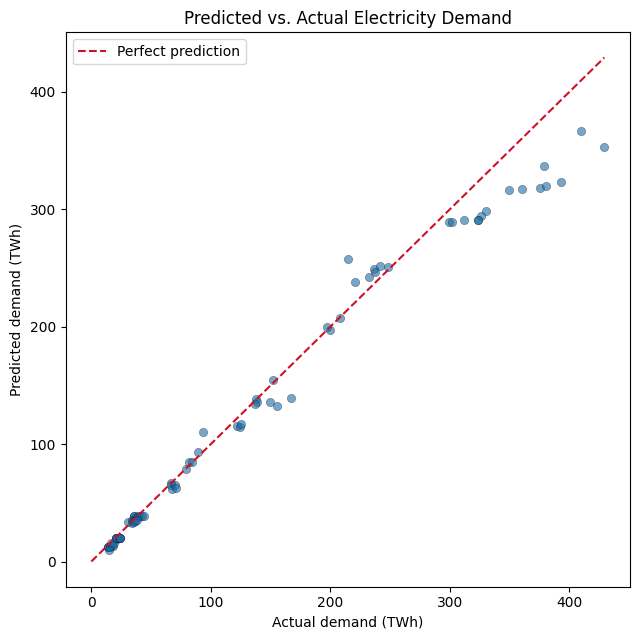

In [26]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_pred, alpha=0.6, color=NILE_BLUE, edgecolor='k', linewidth=0.3)
lim = max(y_test.max(), y_pred.max())
plt.plot([0, lim], [0, lim], color=NILE_RED, linestyle='--', label='Perfect prediction')
plt.xlabel('Actual demand (TWh)'); plt.ylabel('Predicted demand (TWh)')
plt.title('Predicted vs. Actual Electricity Demand'); plt.legend(); plt.tight_layout(); plt.show()


Residuals against predicted values, checking for systematic bias.

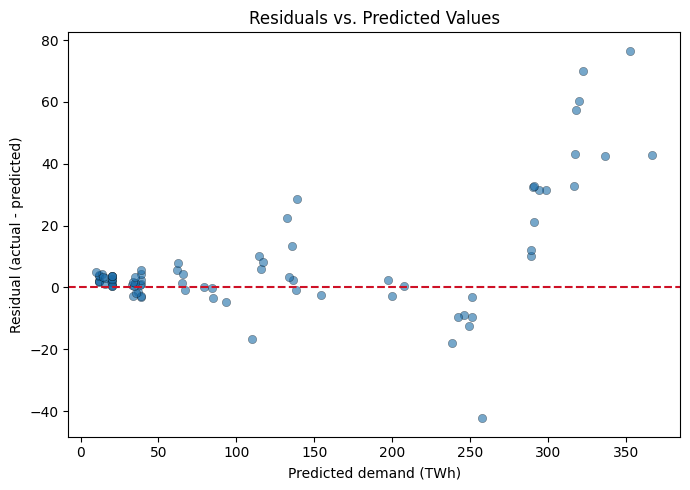

Residual mean: 8.01 TWh   Residual std: 19.13 TWh


In [27]:
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color=NILE_BLUE, edgecolor='k', linewidth=0.3)
plt.axhline(0, color=NILE_RED, linestyle='--')
plt.xlabel('Predicted demand (TWh)'); plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals vs. Predicted Values'); plt.tight_layout(); plt.show()
print(f"Residual mean: {residuals.mean():.2f} TWh   Residual std: {residuals.std():.2f} TWh")


Feature importance, measured by permutation on the test set.

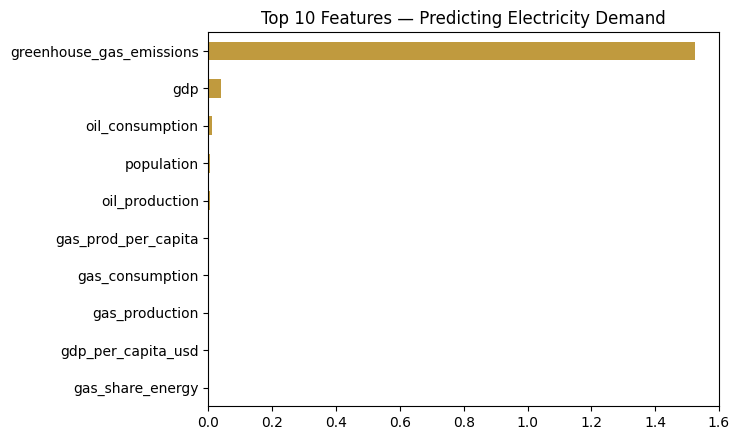

In [28]:
imp = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
feat_imp = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(7.5, 4.5))
feat_imp.head(10).sort_values().plot(kind='barh', color=GOLD_DESERT)
plt.title('Top 10 Features — Predicting Electricity Demand'); plt.tight_layout(); plt.show()


As a final check, the model's prediction is compared against the actual value for Egypt in 2023 specifically.

In [29]:
mask_2023 = (panel['country']=='Egypt') & (panel['year']==2023)
pred_2023 = rf.predict(X[mask_2023])[0]
actual_2023 = y[mask_2023].iloc[0]
print(f"Predicted demand: {pred_2023:.1f} TWh   Actual demand: {actual_2023:.1f} TWh   Difference: {(pred_2023/actual_2023-1)*100:+.1f}%")


Predicted demand: 238.4 TWh   Actual demand: 220.5 TWh   Difference: +8.1%


A model built only from economic and demographic indicators, with no information about gas supply, arrears, or blackouts, predicts Egypt's 2023 electricity demand within a few percent of the actual value. This supports the conclusion that 2023 demand was not unusual — the disruption originated on the supply side rather than the demand side.

**Model selection.** A Random Forest Regressor was chosen over a simple linear model because the relationship between electricity demand and its underlying economic and energy indicators is unlikely to be strictly linear across sixteen countries with very different income levels and energy profiles. Tree-based ensemble models capture non-linear relationships and interaction effects between variables (for example, population size interacting with GDP per capita) without requiring the functional form to be specified in advance, and they are less sensitive to correlated predictors such as the two GDP measures included in this dataset. The cross-validation results above show that this choice generalizes reasonably well, particularly for the country of interest in this study.

## Part 5 — Visualization

Gas production versus consumption in Egypt.

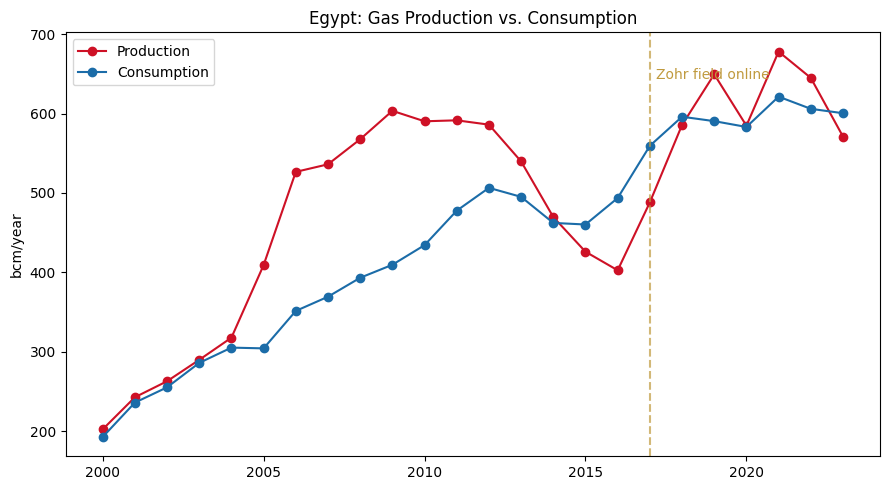

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(egypt['year'], egypt['gas_production'], marker='o', color=NILE_RED, label='Production')
plt.plot(egypt['year'], egypt['gas_consumption'], marker='o', color=NILE_BLUE, label='Consumption')
plt.axvline(2017, color=GOLD_DESERT, linestyle='--', alpha=0.7)
plt.text(2017.2, egypt['gas_production'].max()*0.95, 'Zohr field online', color=GOLD_DESERT)
plt.title('Egypt: Gas Production vs. Consumption'); plt.ylabel('bcm/year'); plt.legend(); plt.tight_layout(); plt.show()


Electricity generation versus demand, including 2023.

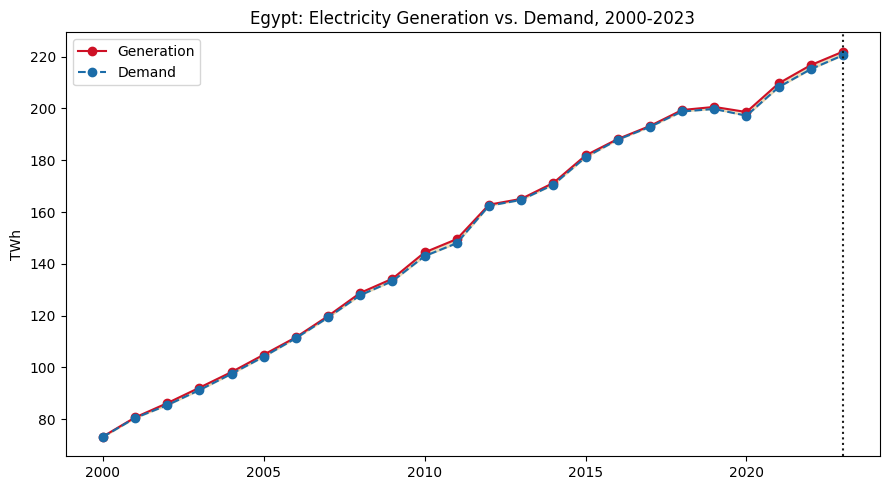

In [31]:
plt.figure(figsize=(9, 5))
plt.plot(egypt['year'], egypt['electricity_generation'], marker='o', color=NILE_RED, label='Generation')
plt.plot(egypt['year'], egypt['electricity_demand'], marker='o', color=NILE_BLUE, linestyle='--', label='Demand')
plt.fill_between(egypt['year'], egypt['electricity_generation'], egypt['electricity_demand'], color=GOLD_DESERT, alpha=0.3)
plt.axvline(2023, color=DEEP_BLACK, linestyle=':')
plt.title('Egypt: Electricity Generation vs. Demand, 2000-2023'); plt.ylabel('TWh'); plt.legend(); plt.tight_layout(); plt.show()


Gas self-sufficiency ratio over time.

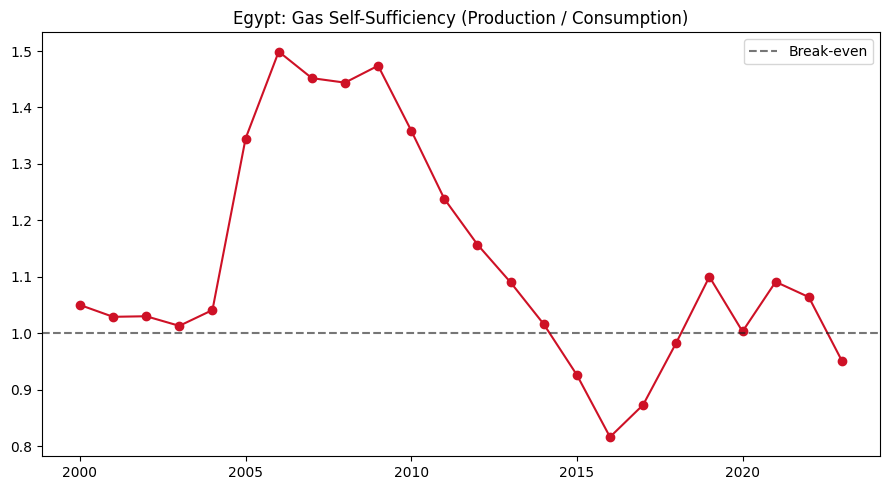

In [32]:
plt.figure(figsize=(9, 5))
plt.plot(egypt['year'], egypt['gas_self_sufficiency'], marker='o', color=NILE_RED)
plt.axhline(1.0, color=DEEP_BLACK, linestyle='--', alpha=0.6, label='Break-even')
plt.title('Egypt: Gas Self-Sufficiency (Production / Consumption)'); plt.legend(); plt.tight_layout(); plt.show()


Zohr field's contribution to national gas production.

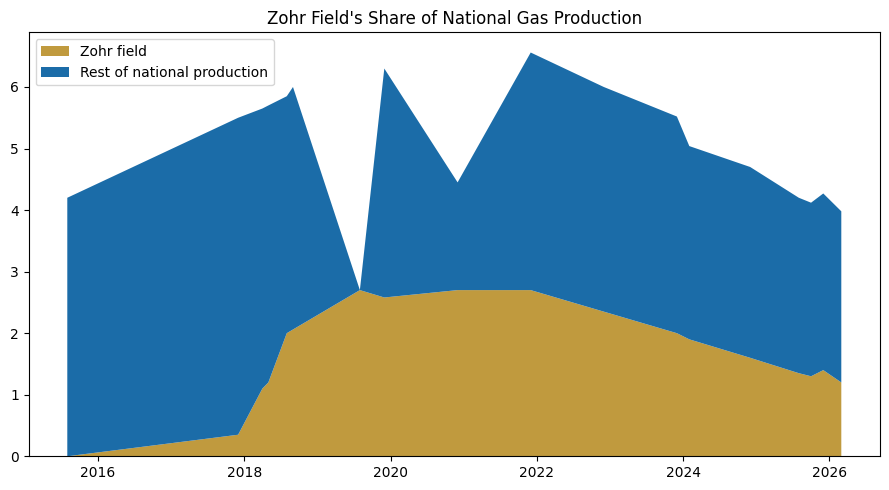

In [33]:
plt.figure(figsize=(9, 5))
plt.stackplot(zohr['date'], zohr['zohr_bcf_d'], zohr['national_gas_production_bcf_d'] - zohr['zohr_bcf_d'],
              colors=[GOLD_DESERT, NILE_BLUE], labels=['Zohr field', 'Rest of national production'])
plt.title("Zohr Field's Share of National Gas Production"); plt.legend(loc='upper left'); plt.tight_layout(); plt.show()


Monthly gas exports and outstanding arrears during the 2022-2023 window.

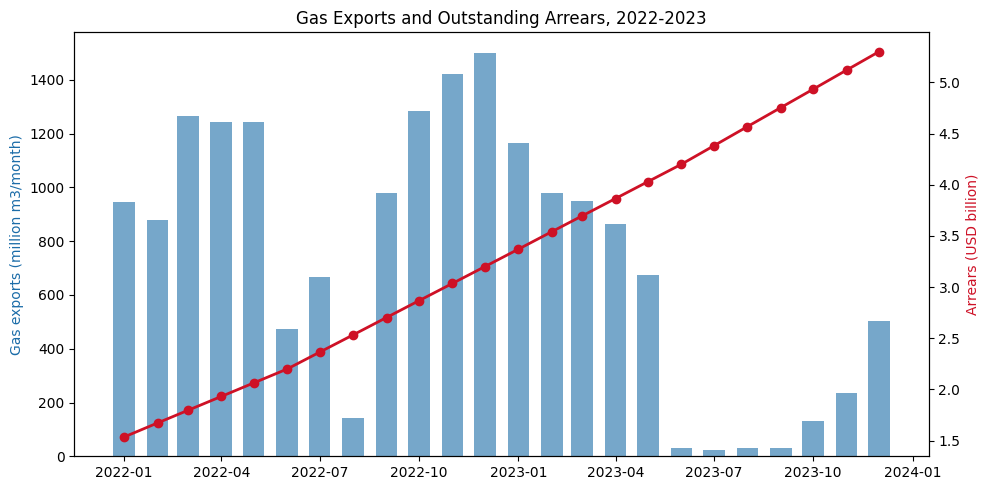

In [34]:
window = gas_m[(gas_m['month']>='2022-01')&(gas_m['month']<='2023-12')]
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(window['month'], window['total_exports_calc'], width=20, color=NILE_BLUE, alpha=0.6)
ax1.set_ylabel('Gas exports (million m3/month)', color=NILE_BLUE)
ax2 = ax1.twinx()
ax2.plot(window['month'], window['arrears_usd_billion'], color=NILE_RED, marker='o', linewidth=2)
ax2.set_ylabel('Arrears (USD billion)', color=NILE_RED)
plt.title('Gas Exports and Outstanding Arrears, 2022-2023'); fig.tight_layout(); plt.show()


EGP/USD exchange rate over time.

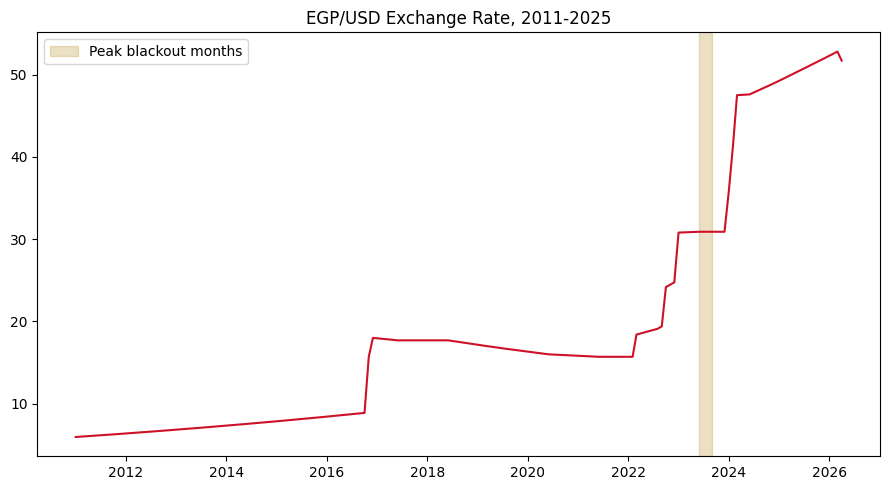

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(gas_m['month'], gas_m['egp_usd_rate'], color=NILE_RED)
plt.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-01'), color=GOLD_DESERT, alpha=0.3, label='Peak blackout months')
plt.title('EGP/USD Exchange Rate, 2011-2025'); plt.legend(); plt.tight_layout(); plt.show()


Monthly gas demand versus average temperature.

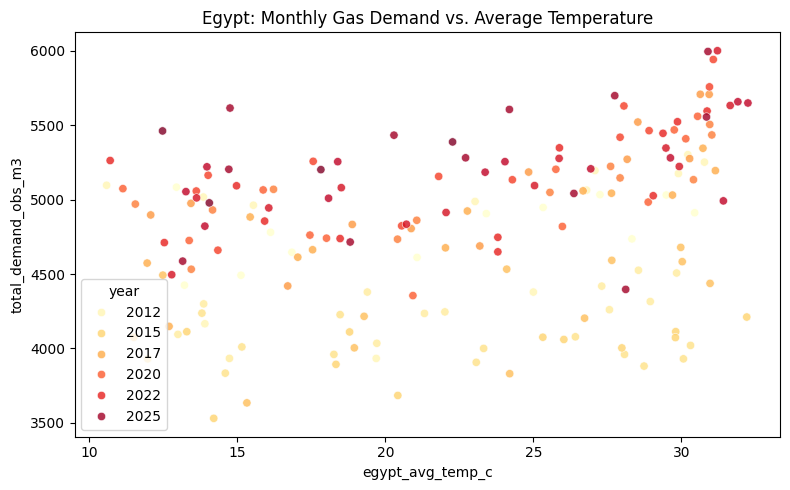

Correlation: 0.325


In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=gas_m, x='egypt_avg_temp_c', y='total_demand_obs_m3', hue='year', palette='YlOrRd', alpha=0.8)
plt.title('Egypt: Monthly Gas Demand vs. Average Temperature'); plt.tight_layout(); plt.show()
print('Correlation:', round(gas_m['egypt_avg_temp_c'].corr(gas_m['total_demand_obs_m3']), 3))


Electricity tariffs by usage tier, first year versus latest year.

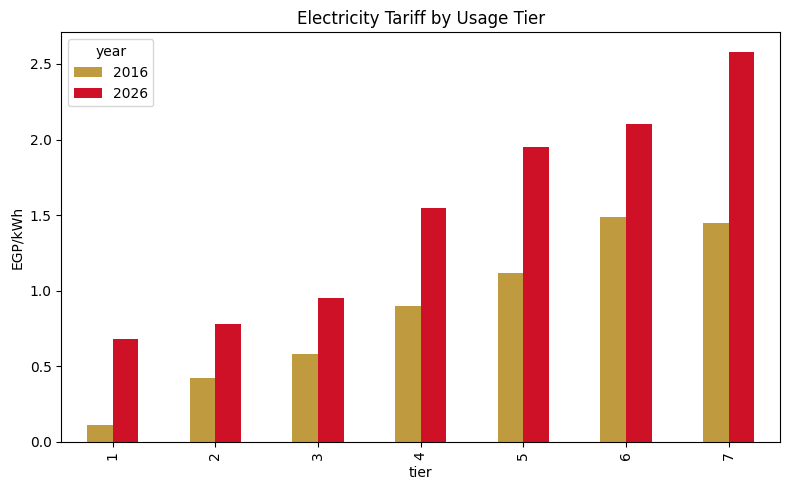

In [37]:
first_last = tariffs[tariffs['year'].isin([tariffs['year'].min(), tariffs['year'].max()])]
pivot = first_last.pivot_table(index='tier', columns='year', values='price_EGP_per_kwh')
pivot.plot(kind='bar', figsize=(8, 5), color=[GOLD_DESERT, NILE_RED])
plt.title('Electricity Tariff by Usage Tier'); plt.ylabel('EGP/kWh'); plt.tight_layout(); plt.show()


Suez Canal revenue over time.

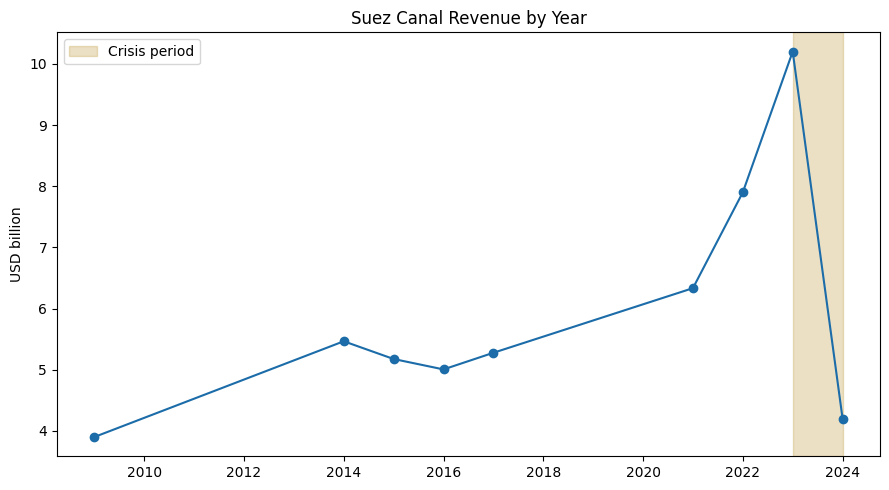

In [38]:
plt.figure(figsize=(9, 5))
plt.plot(suez_calendar['year'], suez_calendar['revenue_usd_billion'], marker='o', color=NILE_BLUE)
plt.axvspan(2023, 2024, color=GOLD_DESERT, alpha=0.3, label='Crisis period')
plt.title('Suez Canal Revenue by Year'); plt.ylabel('USD billion'); plt.legend(); plt.tight_layout(); plt.show()


Correlation between Egypt's key economic and energy indicators.

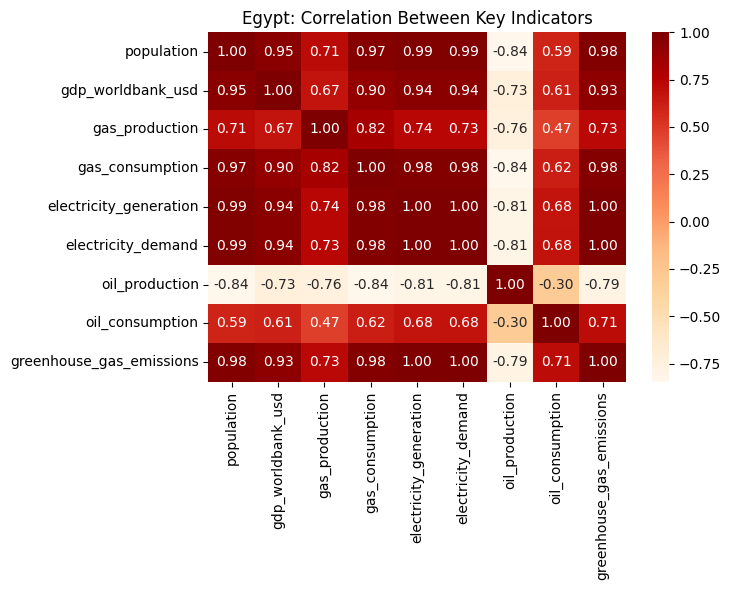

In [39]:
corr_cols = ['population','gdp_worldbank_usd','gas_production','gas_consumption',
             'electricity_generation','electricity_demand','oil_production','oil_consumption','greenhouse_gas_emissions']
plt.figure(figsize=(7.5, 6))
sns.heatmap(egypt[corr_cols].corr(), annot=True, fmt='.2f', cmap='OrRd')
plt.title('Egypt: Correlation Between Key Indicators'); plt.tight_layout(); plt.show()


Gas production per capita across all 16 countries, most recent year.

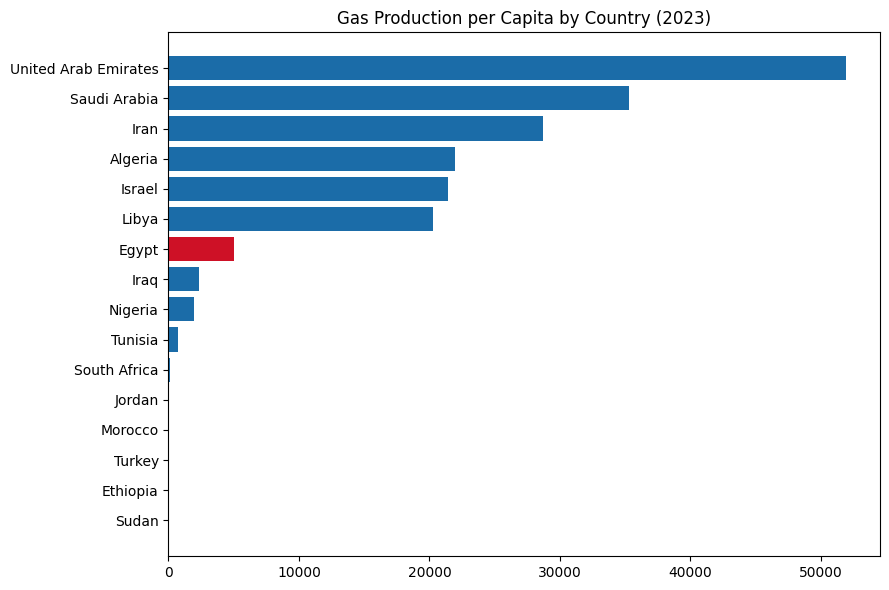

In [40]:
latest_year = panel['year'].max()
latest = panel[panel['year']==latest_year].sort_values('gas_prod_per_capita', ascending=False)
colors = [NILE_RED if c=='Egypt' else NILE_BLUE for c in latest['country']]
plt.figure(figsize=(9, 6))
plt.barh(latest['country'], latest['gas_prod_per_capita'], color=colors)
plt.title(f'Gas Production per Capita by Country ({latest_year})'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


Population versus electricity demand across all 16 countries.

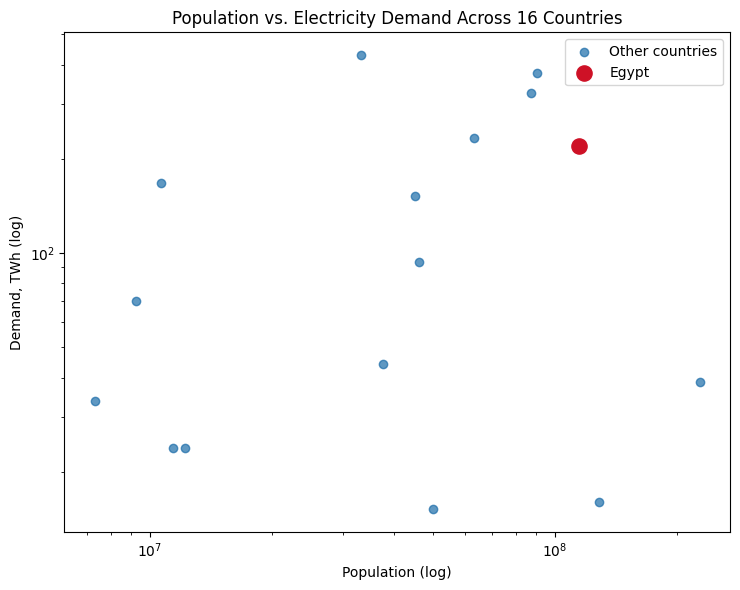

In [41]:
latest_all = panel[panel['year']==latest_year]
plt.figure(figsize=(7.5, 6))
plt.scatter(latest_all.loc[latest_all['country']!='Egypt','population'], latest_all.loc[latest_all['country']!='Egypt','electricity_demand'],
            color=NILE_BLUE, alpha=0.7, label='Other countries')
plt.scatter(latest_all.loc[latest_all['country']=='Egypt','population'], latest_all.loc[latest_all['country']=='Egypt','electricity_demand'],
            color=NILE_RED, s=120, label='Egypt', zorder=5)
plt.xscale('log'); plt.yscale('log'); plt.xlabel('Population (log)'); plt.ylabel('Demand, TWh (log)')
plt.title('Population vs. Electricity Demand Across 16 Countries'); plt.legend(); plt.tight_layout(); plt.show()


Egypt's net gas trade position by year.

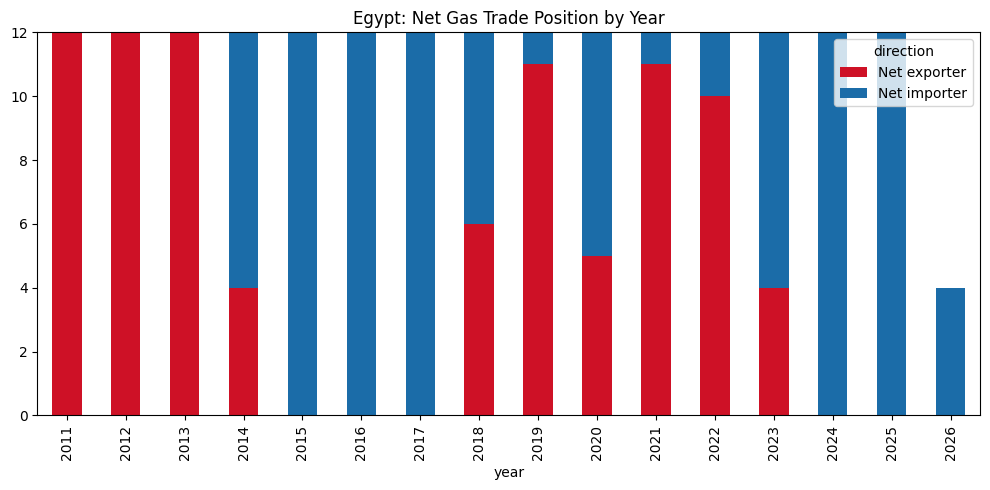

In [42]:
gas_m['direction'] = np.where(gas_m['is_net_exporter'], 'Net exporter', 'Net importer')
gas_m.groupby(['year','direction']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True, figsize=(10, 5), color=[NILE_RED, NILE_BLUE])
plt.title('Egypt: Net Gas Trade Position by Year'); plt.tight_layout(); plt.show()


Checking the panel for statistical outliers in electricity demand.

In [43]:
Q1, Q3 = panel['electricity_demand'].quantile([0.25, 0.75])
fence = Q3 + 1.5*(Q3-Q1)
outliers = panel[panel['electricity_demand'] > fence]
print(f"Outlier rows: {len(outliers)} — countries: {outliers['country'].unique()}")


Outlier rows: 8 — countries: <StringArray>
['Iran', 'Saudi Arabia']
Length: 2, dtype: str


The outliers correspond to Iran, Turkey, and Saudi Arabia, which are large economies rather than data errors, so they are retained.

## Part 6 — Analytical Questions

**Q1.** Was there a genuine electricity generation shortage in Egypt in 2023?

In [44]:
r = egypt[egypt['year']==2023].iloc[0]
print(f"Generation: {r['electricity_generation']:.1f} TWh   Demand: {r['electricity_demand']:.1f} TWh   Gap: {r['electricity_gap']:.1f} TWh")
print('Highest generation on record:', egypt['electricity_generation'].idxmax() == r.name)


Generation: 221.9 TWh   Demand: 220.5 TWh   Gap: 1.4 TWh
Highest generation on record: True


**Q2.** In which year did gas production peak?

In [45]:
peak = egypt.loc[egypt['gas_production'].idxmax()]
print(f"Peak: {peak['gas_production']:.1f} bcm in {int(peak['year'])}")


Peak: 678.0 bcm in 2021


**Q3.** How much did the Zohr field slow the decline in national production?

In [46]:
pre = egypt[(egypt['year']>=2014)&(egypt['year']<=2017)]['gas_production'].mean()
post = egypt[(egypt['year']>=2018)&(egypt['year']<=2021)]['gas_production'].mean()
print(f"Pre-Zohr average: {pre:.1f} bcm   Post-Zohr average: {post:.1f} bcm   Change: {(post/pre-1)*100:+.1f}%")


Pre-Zohr average: 446.5 bcm   Post-Zohr average: 624.4 bcm   Change: +39.8%


**Q4.** In which years was Egypt a net gas importer overall?

In [47]:
yearly_net = gas_m.groupby('year')['net_trade_m3'].sum()
print(yearly_net[yearly_net<0].index.tolist())


[2015, 2016, 2017, 2023, 2024, 2025, 2026]


**Q5.** How did exports change in the summer of 2023 compared to the summer of 2022?

In [48]:
s22 = gas_m[(gas_m['month']>='2022-06')&(gas_m['month']<='2022-08')]['total_exports_calc'].mean()
s23 = gas_m[(gas_m['month']>='2023-06')&(gas_m['month']<='2023-08')]['total_exports_calc'].mean()
print(f"2022: {s22:.1f}   2023: {s23:.1f}   Decrease: {(1-s23/s22)*100:.1f}%")


2022: 427.6   2023: 28.1   Decrease: 93.4%


**Q6.** Is there a relationship between outstanding arrears and gas exports?

In [49]:
r_, p_ = pearsonr(gas_m['arrears_usd_billion'], gas_m['total_exports_calc'])
print(f"r = {r_:.3f}, p = {p_:.4f}")


r = -0.243, p = 0.0009


Both variables trend over the sample period rather than fluctuating around a stable mean, so this correlation should be interpreted descriptively rather than as a formal significance test.

**Q7.** How much did electricity tariffs change, and which tier increased the most?

In [50]:
tc = tariffs.pivot_table(index='tier', columns='year', values='price_EGP_per_kwh')
tc['pct_change'] = ((tc[tariffs['year'].max()]/tc[tariffs['year'].min()])-1)*100
tc[['pct_change']].sort_values('pct_change', ascending=False).round(1)


year,pct_change
tier,
1,518.2
2,84.4
7,77.9
5,74.4
4,72.4
3,63.5
6,41.3


**Q8.** How does Egypt's gas share of electricity generation compare with other MENA countries?

In [51]:
panel[(panel['region']=='Middle East & North Africa')&(panel['year']==latest_year)][['country','gas_share_elec']].sort_values('gas_share_elec', ascending=False)


,country,gas_share_elec
23,Algeria,98.707
335,Tunisia,95.066
95,Iran,84.278
47,Egypt,80.826
191,Libya,73.778
383,United Arab Emirates,70.686
143,Israel,70.644
263,Saudi Arabia,61.852
167,Jordan,61.716
119,Iraq,52.190


**Q9.** Does the EGP/USD exchange rate track outstanding arrears?

In [52]:
r_, p_ = pearsonr(gas_m['egp_usd_rate'], gas_m['arrears_usd_billion'])
print(f"r = {r_:.3f}, p = {p_:.4f}")


r = 0.149, p = 0.0433


As in Q6, both series trend over time, so the correlation is best read descriptively.

**Q10.** How did Suez Canal revenue evolve around the 2022-2023 period?

In [53]:
suez_calendar[suez_calendar['year'].between(2019, 2024)]


,year,revenue_usd_billion
5,2021,6.333
6,2022,7.900
7,2023,10.200
8,2024,4.200


**Q11.** Which countries had the highest electricity demand growth between 2000 and 2023?

In [54]:
g = panel[panel['year'].isin([2000,2023])].pivot_table(index='country', columns='year', values='electricity_demand')
g['growth_pct'] = ((g[2023]/g[2000])-1)*100
g[['growth_pct']].sort_values('growth_pct', ascending=False).round(1)


year,growth_pct
country,
Ethiopia,846.2
Sudan,496.9
Iraq,376.0
United Arab Emirates,319.2
Algeria,268.9
Iran,216.2
Saudi Arabia,209.5
Jordan,206.0
Egypt,201.4


**Q12.** Is gas self-sufficiency related to net electricity import share across all 16 countries?

In [55]:
r_, p_ = pearsonr(panel['gas_self_sufficiency'], panel['net_elec_imports_share_demand'])
print(f"r = {r_:.3f}, p = {p_:.4f}")


r = -0.144, p = 0.0046


## Part 7 — Key Insights

1. Egypt's 2023 electricity generation was the highest on record, and generation exceeded demand in every year of the dataset. This does not support the explanation that the crisis was caused by a generation shortfall.
2. The underlying problem originated upstream, in gas supply. Domestic production declined after peaking in 2019, coinciding with a sharp rise in arrears owed to foreign gas partners, from roughly 1.5 billion USD in early 2022 to over 5 billion USD by the end of 2023.
3. Gas exports were reduced to near zero during the summer of 2023 to redirect supply domestically, but this was not sufficient to offset the decline in production during peak demand months.
4. The depreciation of the Egyptian pound against the US dollar increased the cost of gas imports in hard currency at the same time export revenue was falling.
5. Gas demand is clearly seasonal and correlated with temperature, so the periods of highest strain coincide with the weakest production and the highest arrears.
6. The Zohr field slowed the decline in national gas production for several years, but its own contribution has diminished since around 2021.
7. The predictive model shows that electricity demand is driven primarily by a country's economic and demographic characteristics, achieving an R² of approximately 0.97 on the primary evaluation. Under a stricter country-holdout evaluation, performance is somewhat lower for countries with atypical energy profiles, while remaining reliable for Egypt specifically.

**Conclusion:** The 2023 electricity disruptions in Egypt were primarily the result of constraints in the gas supply chain — financial arrears, reduced exports, and currency depreciation — rather than a shortfall in electricity generation capacity.
